# Nettoyage + équilibrage du dataset LIAR

Objectif :
1. Charger `train.csv`, `valid.csv`, `test.csv`
2. Supprimer les valeurs aberrantes de labels
3. Nettoyer les lignes invalides
4. Équilibrer les labels (multiclasse)
5. Exporter les jeux nettoyés

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 160)

In [7]:
# Chargement des 3 fichiers LIAR (train/valid/test)
code_dir = (Path.cwd() / "code").resolve()
train_path = code_dir / "train.csv"
valid_path = code_dir / "valid.csv"
test_path = code_dir / "test.csv"

for p in [train_path, valid_path, test_path]:
    if not p.exists():
        raise FileNotFoundError(f"Fichier introuvable: {p}")

cols = [
    "id", "label", "statement", "subject", "speaker", "job_title",
    "state_info", "party", "barely_true_counts", "false_counts",
    "half_true_counts", "mostly_true_counts", "pants_on_fire_counts", "context"
]

df_train = pd.read_csv(train_path, sep="\t", header=None, names=cols, dtype=str)
df_valid = pd.read_csv(valid_path, sep="\t", header=None, names=cols, dtype=str)
df_test = pd.read_csv(test_path, sep="\t", header=None, names=cols, dtype=str)

df_train["split"] = "train"
df_valid["split"] = "valid"
df_test["split"] = "test"

df = pd.concat([df_train, df_valid, df_test], ignore_index=True)

print(f"Fichiers chargés depuis : {code_dir}")
print(f"Shape initiale globale : {df.shape}")
display(df["split"].value_counts().to_frame("count"))
df.head()

Fichiers chargés depuis : /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/code
Shape initiale globale : (12791, 15)


,count
split,
train,10240
valid,1284
test,1267


,id,label,statement,subject,speaker,job_title,state_info,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,split
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,abortion,dwayne-bohac,State representative,Texas,republican,0,1,0,0,0,a mailer,train
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,"energy,history,job-accomplishments",scott-surovell,State delegate,Virginia,democrat,0,0,1,1,0,a floor speech.,train
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,Denver,train
3,1123.json,false,Health care reform legislation is likely to mandate free sex change surgeries.,health-care,blog-posting,NaN,NaN,none,7,19,3,5,44,a news release,train
4,9028.json,half-true,The economic turnaround started at the end of my term.,"economy,jobs",charlie-crist,NaN,Florida,democrat,15,9,20,19,2,an interview on CNN,train


In [8]:
# Vérification des colonnes
required_cols = ["id", "label", "statement", "split"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Colonnes manquantes: {missing_cols}")

display(df[required_cols].head(3))
print("\nRépartition brute des labels:")
display(df["label"].value_counts(dropna=False).to_frame("count"))
print("\nRépartition brute par split:")
display(pd.crosstab(df["split"], df["label"]))

,id,label,statement,split
0,2635.json,false,Says the Annies List political group supports third-trimester abortions on demand.,train
1,10540.json,half-true,When did the decline of coal start? It started when natural gas took off that started to begin in (President George W.) Bushs administration.,train
2,324.json,mostly-true,"Hillary Clinton agrees with John McCain ""by voting to give George Bush the benefit of the doubt on Iran.""",train



Répartition brute des labels:


,count
label,
half-true,2627
false,2507
mostly-true,2454
barely-true,2103
true,2053
pants-fire,1047



Répartition brute par split:


label,barely-true,false,half-true,mostly-true,pants-fire,true
split,,,,,,
test,212,249,265,241,92,208
train,1654,1995,2114,1962,839,1676
valid,237,263,248,251,116,169


In [9]:
# Nettoyage des labels et suppression des valeurs aberrantes
VALID_LABELS = {
    "pants-fire",
    "false",
    "barely-true",
    "half-true",
    "mostly-true",
    "true",
}

def normalize_label(x):
    if pd.isna(x):
        return np.nan
    x = str(x).strip().lower()
    x = x.replace("pants on fire", "pants-fire").replace("pants_on_fire", "pants-fire")
    return x

df["label_clean"] = df["label"].apply(normalize_label)

mask_aberrant = ~df["label_clean"].isin(VALID_LABELS)
aberrant_rows = df[mask_aberrant].copy()

print(f"Nombre de labels aberrants supprimés : {mask_aberrant.sum()}")
if len(aberrant_rows) > 0:
    display(aberrant_rows[["id", "label", "label_clean"]].head(20))

df_clean = df[~mask_aberrant].copy()

# Nettoyage complémentaire
before = len(df_clean)
df_clean = df_clean.dropna(subset=["statement", "label_clean"])
df_clean = df_clean[df_clean["statement"].astype(str).str.strip() != ""]
df_clean = df_clean.drop_duplicates(subset=["id"], keep="first")
after = len(df_clean)
print(f"Lignes supprimées au nettoyage complémentaire : {before - after}")
print(f"Shape après nettoyage : {df_clean.shape}")

Nombre de labels aberrants supprimés : 0
Lignes supprimées au nettoyage complémentaire : 0
Shape après nettoyage : (12791, 16)


,count
label_clean,
half-true,2627
false,2507
mostly-true,2454
barely-true,2103
true,2053
pants-fire,1047


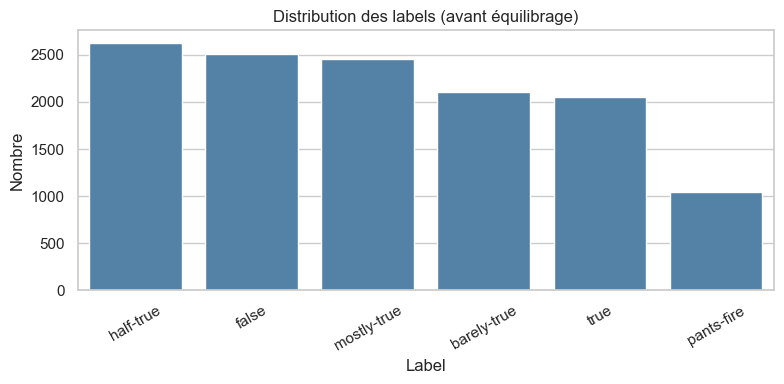

In [10]:
# Déséquilibre des classes avant équilibrage
counts_before = df_clean["label_clean"].value_counts().sort_values(ascending=False)
display(counts_before.to_frame("count"))

plt.figure(figsize=(8, 4))
sns.barplot(x=counts_before.index, y=counts_before.values, color="steelblue")
plt.title("Distribution des labels (avant équilibrage)")
plt.xlabel("Label")
plt.ylabel("Nombre")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [11]:
# Équilibrage des labels (undersampling)
min_count_global = df_clean["label_clean"].value_counts().min()
print(f"Taille cible globale par classe : {min_count_global}")

df_balanced = (
    df_clean.groupby("label_clean", group_keys=False)
    .sample(n=min_count_global, random_state=42)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f"Shape équilibrée globale : {df_balanced.shape}")
display(df_balanced["label_clean"].value_counts().to_frame("count"))

# Équilibrage par split (utile pour garder train/valid/test séparés)
split_class_counts = df_clean.groupby(["split", "label_clean"]).size()
min_per_split = split_class_counts.groupby(level=0).min().to_dict()
print("\nTaille cible par split:", min_per_split)

balanced_parts = []
for split_name, split_df in df_clean.groupby("split"):
    n_target = min_per_split[split_name]
    part = (
        split_df.groupby("label_clean", group_keys=False)
        .sample(n=n_target, random_state=42)
    )
    balanced_parts.append(part)

df_balanced_split = (
    pd.concat(balanced_parts, ignore_index=True)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print(f"Shape équilibrée par split : {df_balanced_split.shape}")
display(pd.crosstab(df_balanced_split["split"], df_balanced_split["label_clean"]))

Taille cible globale par classe : 1047
Shape équilibrée globale : (6282, 16)


,count
label_clean,
half-true,1047
true,1047
mostly-true,1047
barely-true,1047
false,1047
pants-fire,1047



Taille cible par split: {'test': 92, 'train': 839, 'valid': 116}
Shape équilibrée par split : (6282, 16)


label_clean,barely-true,false,half-true,mostly-true,pants-fire,true
split,,,,,,
test,92,92,92,92,92,92
train,839,839,839,839,839,839
valid,116,116,116,116,116,116


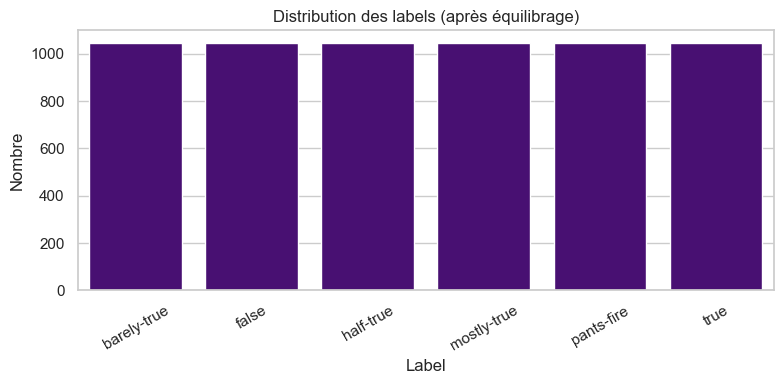

In [12]:
# Visualisation après équilibrage
counts_after = df_balanced["label_clean"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
sns.barplot(x=counts_after.index, y=counts_after.values, color="indigo")
plt.title("Distribution des labels (après équilibrage)")
plt.xlabel("Label")
plt.ylabel("Nombre")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [13]:
# Exports
out_dir = (Path.cwd() / "dataset").resolve()
out_dir.mkdir(parents=True, exist_ok=True)

clean_path = out_dir / "liar_clean.csv"
balanced_path = out_dir / "liar_clean_balanced.csv"
balanced_split_path = out_dir / "liar_clean_balanced_by_split.csv"

df_clean.to_csv(clean_path, index=False)
df_balanced.to_csv(balanced_path, index=False)
df_balanced_split.to_csv(balanced_split_path, index=False)

print(f"Fichier nettoyé: {clean_path}")
print(f"Fichier équilibré global: {balanced_path}")
print(f"Fichier équilibré par split: {balanced_split_path}")

Fichier nettoyé: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_clean.csv
Fichier équilibré global: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_clean_balanced.csv
Fichier équilibré par split: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_clean_balanced_by_split.csv


In [14]:
# Construction binaire + équilibrage
fake_labels = {"pants-fire", "false", "barely-true"}
real_labels = {"mostly-true", "true"}

df_binary = df_clean[df_clean["label_clean"].isin(fake_labels | real_labels)].copy()
df_binary["label_bin"] = np.where(df_binary["label_clean"].isin(fake_labels), 1, 0)

print("Shape binaire (sans half-true):", df_binary.shape)
print("\nRépartition binaire brute:")
display(df_binary["label_bin"].value_counts().rename(index={1: "fake(1)", 0: "real(0)"}).to_frame("count"))
print("\nRépartition binaire brute par split:")
display(pd.crosstab(df_binary["split"], df_binary["label_bin"]))

# Équilibrage binaire global
min_bin_global = df_binary["label_bin"].value_counts().min()
df_binary_balanced = (
    df_binary.groupby("label_bin", group_keys=False)
    .sample(n=min_bin_global, random_state=42)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print("\nShape binaire équilibrée globale:", df_binary_balanced.shape)
display(df_binary_balanced["label_bin"].value_counts().rename(index={1: "fake(1)", 0: "real(0)"}).to_frame("count"))

# Équilibrage binaire par split
min_bin_per_split = df_binary.groupby(["split", "label_bin"]).size().groupby(level=0).min().to_dict()
parts_bin = []
for split_name, split_df in df_binary.groupby("split"):
    n_target = min_bin_per_split[split_name]
    part = split_df.groupby("label_bin", group_keys=False).sample(n=n_target, random_state=42)
    parts_bin.append(part)

df_binary_balanced_split = (
    pd.concat(parts_bin, ignore_index=True)
    .sample(frac=1.0, random_state=42)
    .reset_index(drop=True)
)

print("\nShape binaire équilibrée par split:", df_binary_balanced_split.shape)
display(pd.crosstab(df_binary_balanced_split["split"], df_binary_balanced_split["label_bin"]))

# Exports binaires
binary_clean_path = out_dir / "liar_binary_clean.csv"
binary_balanced_path = out_dir / "liar_binary_balanced.csv"
binary_balanced_split_path = out_dir / "liar_binary_balanced_by_split.csv"

df_binary.to_csv(binary_clean_path, index=False)
df_binary_balanced.to_csv(binary_balanced_path, index=False)
df_binary_balanced_split.to_csv(binary_balanced_split_path, index=False)

print("\nFichier binaire nettoyé:", binary_clean_path)
print("Fichier binaire équilibré global:", binary_balanced_path)
print("Fichier binaire équilibré par split:", binary_balanced_split_path)

Shape binaire (sans half-true): (10164, 17)

Répartition binaire brute:


,count
label_bin,
fake(1),5657
real(0),4507



Répartition binaire brute par split:


label_bin,0,1
split,,
test,449,553
train,3638,4488
valid,420,616



Shape binaire équilibrée globale: (9014, 17)


,count
label_bin,
fake(1),4507
real(0),4507



Shape binaire équilibrée par split: (9014, 17)


label_bin,0,1
split,,
test,449,449
train,3638,3638
valid,420,420



Fichier binaire nettoyé: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_clean.csv
Fichier binaire équilibré global: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_balanced.csv
Fichier binaire équilibré par split: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_balanced_by_split.csv


In [19]:
df_binary_balanced_split.head()

,id,label,statement,subject,speaker,job_title,state_info,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,split,label_clean,label_bin
0,12468.json,pants-fire,"The Dog Meat Festival in Yulin, China, threatens global public health.","animals,public-health",alcee-hastings,U.S. Representative,Florida,democrat,1,0,1,0,2,a House resolution,train,pants-fire,1
1,10411.json,mostly-true,"Starting in December 2007, 1.4 million jobs were created in Texas. In that same period, the rest of the country lost 400,000 jobs.","job-accomplishments,jobs",rick-perry,Governor,Texas,republican,30,30,42,23,18,valedictory speech as governor to the Texas Legislature,train,mostly-true,0
2,5970.json,mostly-true,Says Williamson County Attorney Jana Duty has never prosecuted a single adult felony case.,candidates-biography,john-bradley,Williamson County district attorney,Texas,republican,0,0,0,1,0,an op-ed in the Austin American-Statesman,train,mostly-true,0
3,2927.json,barely-true,Cities like Seattle have decided to ban food carts.,"food-safety,market-regulation",randy-leonard,Portland city commissioner,Oregon,none,1,0,0,0,0,a city council meeting,train,barely-true,1
4,753.json,mostly-true,"McCain ""said the other day that he would not meet potentially with the prime minister of Spain, because he . . . wasn't sure whether they were aligned with ...",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,"a debate in Oxford, Miss.",train,mostly-true,0


## Version binaire (fake vs real)

Règle appliquée :
- `fake` = `pants-fire`, `false`, `barely-true` → `label_bin = 1`
- `real` = `mostly-true`, `true` → `label_bin = 0`
- `half-true` est supprimé (classe ambiguë).

## Encodage BERT (texte -> numérique)

Cette section transforme `statement` en vecteurs numériques BERT pour entraîner ton modèle LIAR binaire.

Sorties générées dans `dataset/` :
- `liar_binary_bert_embeddings.npy` (matrice X)
- `liar_binary_bert_labels.npy` (vecteur y)
- `liar_binary_bert_meta.csv` (id, split, label)

In [16]:
import numpy as np
import pandas as pd
from pathlib import Path
import torch
from transformers import AutoTokenizer, AutoModel

# Charger la base binaire équilibrée par split si non présente
if "df_binary_balanced_split" not in globals():
    if "out_dir" not in globals():
        out_dir = (Path.cwd() / "dataset").resolve()
    fallback_path = out_dir / "liar_binary_balanced_by_split.csv"
    if not fallback_path.exists():
        raise FileNotFoundError(f"Fichier introuvable: {fallback_path}")
    df_binary_balanced_split = pd.read_csv(fallback_path)

df_bert = df_binary_balanced_split.copy()
df_bert["statement"] = df_bert["statement"].fillna("").astype(str)

print("Shape source BERT:", df_bert.shape)
display(df_bert[["id", "split", "label_bin", "statement"]].head(3))

model_name = "bert-base-uncased"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name).to(device)
model.eval()

def bert_encode_texts(texts, batch_size=32, max_length=128):
    all_embeddings = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt"
        )
        encoded = {k: v.to(device) for k, v in encoded.items()}

        with torch.no_grad():
            outputs = model(**encoded)
            token_embeddings = outputs.last_hidden_state
            attention_mask = encoded["attention_mask"].unsqueeze(-1)
            masked = token_embeddings * attention_mask
            sum_embeddings = masked.sum(dim=1)
            lengths = attention_mask.sum(dim=1).clamp(min=1)
            mean_pooled = sum_embeddings / lengths
            all_embeddings.append(mean_pooled.cpu())

    return torch.cat(all_embeddings, dim=0).numpy()

texts = df_bert["statement"].tolist()
X_bert = bert_encode_texts(texts, batch_size=32, max_length=128)
y_bert = df_bert["label_bin"].astype(int).to_numpy()

print("Embeddings shape:", X_bert.shape)
print("Labels shape:", y_bert.shape)

# Exports
emb_path = out_dir / "liar_binary_bert_embeddings.npy"
y_path = out_dir / "liar_binary_bert_labels.npy"
meta_path = out_dir / "liar_binary_bert_meta.csv"

np.save(emb_path, X_bert)
np.save(y_path, y_bert)
df_bert[["id", "split", "label_bin"]].to_csv(meta_path, index=False)

print("Embeddings:", emb_path)
print("Labels:", y_path)
print("Meta:", meta_path)

Shape source BERT: (9014, 17)


,id,split,label_bin,statement
0,12468.json,train,1,"The Dog Meat Festival in Yulin, China, threatens global public health."
1,10411.json,train,0,"Starting in December 2007, 1.4 million jobs were created in Texas. In that same period, the rest of the country lost 400,000 jobs."
2,5970.json,train,0,Says Williamson County Attorney Jana Duty has never prosecuted a single adult felony case.


Device: cpu


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5057.45it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embeddings shape: (9014, 768)
Labels shape: (9014,)
Embeddings: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_bert_embeddings.npy
Labels: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_bert_labels.npy
Meta: /Users/martinvalentine/Projet spe 3 fake news/grp3_projet3_data/valentine/FakeNewsNet-master/dataset/liar_binary_bert_meta.csv


In [17]:
df_bert.head()

,id,label,statement,subject,speaker,job_title,state_info,party,barely_true_counts,false_counts,half_true_counts,mostly_true_counts,pants_on_fire_counts,context,split,label_clean,label_bin
0,12468.json,pants-fire,"The Dog Meat Festival in Yulin, China, threatens global public health.","animals,public-health",alcee-hastings,U.S. Representative,Florida,democrat,1,0,1,0,2,a House resolution,train,pants-fire,1
1,10411.json,mostly-true,"Starting in December 2007, 1.4 million jobs were created in Texas. In that same period, the rest of the country lost 400,000 jobs.","job-accomplishments,jobs",rick-perry,Governor,Texas,republican,30,30,42,23,18,valedictory speech as governor to the Texas Legislature,train,mostly-true,0
2,5970.json,mostly-true,Says Williamson County Attorney Jana Duty has never prosecuted a single adult felony case.,candidates-biography,john-bradley,Williamson County district attorney,Texas,republican,0,0,0,1,0,an op-ed in the Austin American-Statesman,train,mostly-true,0
3,2927.json,barely-true,Cities like Seattle have decided to ban food carts.,"food-safety,market-regulation",randy-leonard,Portland city commissioner,Oregon,none,1,0,0,0,0,a city council meeting,train,barely-true,1
4,753.json,mostly-true,"McCain ""said the other day that he would not meet potentially with the prime minister of Spain, because he . . . wasn't sure whether they were aligned with ...",foreign-policy,barack-obama,President,Illinois,democrat,70,71,160,163,9,"a debate in Oxford, Miss.",train,mostly-true,0
